# Movie Recommendation System — Data Analytics Project

**Dataset:** TMDB Movies Dataset 2023 (930K+ Movies)  
**Approach:** Content-Based Filtering using Cosine Similarity  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  

---

## Project Overview

This notebook builds a complete end-to-end Movie Recommendation System:
1. **Data Cleaning & Preprocessing** — handle missing values, duplicates, type conversions
2. **Feature Engineering** — create 'tags' from genres + overview
3. **Exploratory Data Analysis** — visualize trends, distributions, correlations
4. **ML Model** — CountVectorizer + Cosine Similarity for recommendations
5. **Export Artifacts** — save processed data for Streamlit app


##  1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(' Libraries imported successfully!')

 Libraries imported successfully!


##  2. Load Dataset

**Source:** [TMDB Movies Dataset 2023](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies)  
The dataset contains 930K+ movies with metadata: title, genres, overview, popularity, vote_average, revenue, etc.  

> **Performance Note:** We sample 50,000 rows for efficient processing while preserving statistical patterns.

In [2]:

# Load dataset — update path if needed
# Download from: https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies


DATASET_PATH = 'TMDB_movie_dataset_v11.csv'  # update this path as needed

if os.path.exists(DATASET_PATH):
    print(f'Loading dataset from: {DATASET_PATH}')
    # Use nrows for a quick preview first
    df_full = pd.read_csv(DATASET_PATH, low_memory=False)
    print(f' Full dataset shape: {df_full.shape}')

    # Sample 50K rows for performance
    SAMPLE_SIZE = 50000
    df = df_full.sample(n=min(SAMPLE_SIZE, len(df_full)), random_state=42).reset_index(drop=True)
    print(f' Working sample shape: {df.shape}')
else:
    print('  Dataset file not found.')
df.head(3)

Loading dataset from: TMDB_movie_dataset_v11.csv
 Full dataset shape: (1400340, 24)
 Working sample shape: (50000, 24)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,54778,Sea of Death,4.2,13,Released,2009-09-02,0,98,False,NaN,...,Tod aus der Tiefe,In the German North Sea a new cellular life fo...,1.678,/122qMiSuKlKlwzjUnb4iABxbhGX.jpg,NaN,"Science Fiction, Thriller, Drama, TV Movie, Ac...","Sat.1, Crazy Film, Epo-Film, ORF","Germany, Austria",German,"disaster, virus, pandemic"
1,783222,Fuengirola,0.0,0,Released,1967-01-01,0,13,False,NaN,...,Fuengirola,Short documentary by the basque filmmaker Chum...,0.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51411,Ma and Pa Kettle Go to Town,6.1,10,Released,1950-04-01,0,79,False,/ko2HeQbRK1OqHTAOji0ufpHvXVp.jpg,...,Ma and Pa Kettle Go to Town,"When Pa wins a jingle-writing contest, he and ...",2.557,/sbtKSsHZsCVmVBTeI0XV1RtP7RF.jpg,The NEWEST and hilarious adventure!,Comedy,Universal International Pictures,United States of America,English,NaN


##  3. Initial Data Exploration

In [3]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
df.info()

=== Dataset Info ===
Shape: (50000, 24)
Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   title                 49999 non-null  object 
 2   vote_average          50000 non-null  float64
 3   vote_count            50000 non-null  int64  
 4   status                50000 non-null  object 
 5   release_date          39187 non-null  object 
 6   revenue               50000 non-null  int64  
 7   runtime               50000 non-null  int64

In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

=== Missing Values ===


,Missing Count,Missing %
homepage,44808,89.62
tagline,43133,86.27
keywords,37508,75.02
backdrop_path,37506,75.01
production_companies,28476,56.95
imdb_id,26329,52.66
production_countries,23916,47.83
spoken_languages,23090,46.18
genres,21879,43.76
poster_path,17545,35.09


In [5]:
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,5.000000e+04,50000.000000,50000.000000,5.000000e+04,50000.00000,5.000000e+04,50000.000000
mean,8.859813e+05,1.575607,14.498760,5.267498e+05,43.82606,2.051856e+05,1.012042
std,4.723082e+05,2.868659,277.322892,1.368731e+07,55.18973,4.593257e+06,7.626075
min,2.600000e+01,0.000000,0.000000,0.000000e+00,0.00000,0.000000e+00,0.000000
25%,4.884110e+05,0.000000,0.000000,0.000000e+00,0.00000,0.000000e+00,0.107100
50%,8.990370e+05,0.000000,0.000000,0.000000e+00,16.00000,0.000000e+00,0.600000
75%,1.300646e+06,1.800000,1.000000,0.000000e+00,85.00000,0.000000e+00,0.711000
max,1.666534e+06,10.000000,24649.000000,1.200000e+09,1200.00000,6.000000e+08,1567.273000


##  4. Data Cleaning

In [6]:
# ── Select important features ──────────────────────────────
FEATURES = ['id', 'title', 'genres', 'overview', 'popularity',
            'vote_average', 'vote_count', 'release_date', 'revenue']

# Keep only columns that exist in the dataset
available_features = [c for c in FEATURES if c in df.columns]
if 'keywords' in df.columns:
    available_features.append('keywords')

movies = df[available_features].copy()
print(f' Selected {len(available_features)} features: {available_features}')
print(f'Shape: {movies.shape}')

 Selected 10 features: ['id', 'title', 'genres', 'overview', 'popularity', 'vote_average', 'vote_count', 'release_date', 'revenue', 'keywords']
Shape: (50000, 10)


In [7]:
# ── Remove duplicates ─────────────────────────────────────
before = len(movies)
movies.drop_duplicates(subset=['title'], keep='first', inplace=True)
movies.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(movies)} duplicate titles. Remaining: {len(movies)}')

Removed 1193 duplicate titles. Remaining: 48807


In [8]:
# ── Handle missing values ─────────────────────────────────
# Fill text fields with empty string
movies['overview'] = movies['overview'].fillna('')
movies['genres'] = movies['genres'].fillna('')
if 'keywords' in movies.columns:
    movies['keywords'] = movies['keywords'].fillna('')

# Fill numeric fields with median / 0
movies['popularity'] = movies['popularity'].fillna(movies['popularity'].median())
movies['vote_average'] = movies['vote_average'].fillna(movies['vote_average'].median())
movies['vote_count'] = movies['vote_count'].fillna(0)
if 'revenue' in movies.columns:
    movies['revenue'] = movies['revenue'].fillna(0)

# Remove rows where title is missing (unusable)
movies.dropna(subset=['title'], inplace=True)
movies.reset_index(drop=True, inplace=True)

print(f' Missing values handled. Shape: {movies.shape}')
print(movies.isnull().sum())

 Missing values handled. Shape: (48806, 10)
id                  0
title               0
genres              0
overview            0
popularity          0
vote_average        0
vote_count          0
release_date    10575
revenue             0
keywords            0
dtype: int64


In [9]:
# ── Type conversions ──────────────────────────────────────
# Parse release_date → datetime
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# Numeric coercion
movies['popularity'] = pd.to_numeric(movies['popularity'], errors='coerce').fillna(0)
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce').fillna(0)
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce').fillna(0)

print(' Data types after conversion:')
print(movies.dtypes)

 Data types after conversion:
id                       int64
title                   object
genres                  object
overview                object
popularity             float64
vote_average           float64
vote_count               int64
release_date    datetime64[ns]
revenue                  int64
keywords                object
dtype: object


##  5. Feature Engineering

In [10]:
# Changing column name
movies['year'] = movies['release_date'].dt.year
print('Extracted year column')
print(movies[['title', 'release_date', 'year']].head(5))

 Extracted year column
                         title release_date    year
0                 Sea of Death   2009-09-02  2009.0
1                   Fuengirola   1967-01-01  1967.0
2  Ma and Pa Kettle Go to Town   1950-04-01  1950.0
3             Anal Centerfolds   2017-01-01  2017.0
4    Amateurs Caught On Cam 19          NaT     NaN


In [11]:
# ── Text cleaning helper ───────────────────────────────────
def clean_text(text):
    """Lowercase, remove special characters, collapse spaces."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()    # collapse whitespace
    return text

def clean_genres(genre_str):
    """Normalise genre string: lower, no spaces, join tokens."""
    if not isinstance(genre_str, str) or genre_str == '':
        return ''
    # Handle both 'Action, Comedy' and '[{"name": "Action"}, ...]' formats
    if genre_str.strip().startswith('['):
        try:
            items = ast.literal_eval(genre_str)
            if isinstance(items, list):
                if len(items) > 0 and isinstance(items[0], dict):
                    return ' '.join(item.get('name', '').lower().replace(' ', '') for item in items)
                else:
                    return ' '.join(str(i).lower().replace(' ', '') for i in items)
        except Exception:
            pass
    return ' '.join(genre_str.lower().replace(',', ' ').split())

print(' Text cleaning functions defined')

 Text cleaning functions defined


In [12]:
# ── Build 'tags' feature ───────────────────────────────────
# tags = cleaned genres + cleaned overview [+ cleaned keywords if available]
movies['genres_clean'] = movies['genres'].apply(clean_genres)
movies['overview_clean'] = movies['overview'].apply(clean_text)

if 'keywords' in movies.columns:
    movies['keywords_clean'] = movies['keywords'].apply(clean_text)
    movies['tags'] = (movies['genres_clean'] + ' '
                      + movies['overview_clean'] + ' '
                      + movies['keywords_clean'])
else:
    movies['tags'] = movies['genres_clean'] + ' ' + movies['overview_clean']

movies['tags'] = movies['tags'].str.strip()

print(' Tags feature created')
print(movies[['title', 'tags']].head(3).to_string())

 Tags feature created
                         title                                                                                                                                                                                                                 tags
0                 Sea of Death                                                                            science fiction thriller drama tv movie action in the german north sea a new cellular life form endangers mankind disaster virus pandemic
1                   Fuengirola                                                                                                                                  short documentary by the basque filmmaker chumy ch mez jos mar a gonz lez castrillo
2  Ma and Pa Kettle Go to Town  comedy when pa wins a jingle writing contest he and ma head for new york city they they get in trouble with gangsters when they lose some stolen money which they had already agreed to deliver to one of the thugs


In [13]:
# ── Remove rows with empty tags (not useful for recommendations) ──
before = len(movies)
movies = movies[movies['tags'].str.strip() != ''].reset_index(drop=True)
print(f'Removed {before - len(movies)} rows with empty tags. Remaining: {len(movies)}')

Removed 6038 rows with empty tags. Remaining: 42768


## 6. Exploratory Data Analysis (EDA)

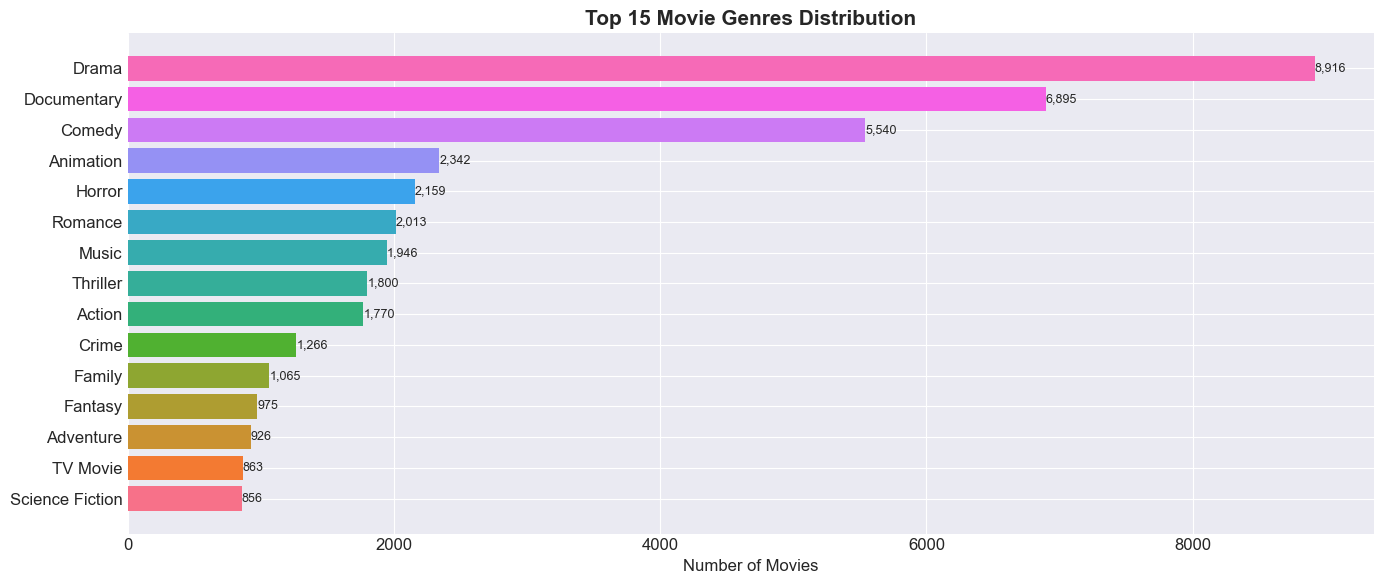

 Genre distribution plot saved


In [14]:
# ── 6.1 Top Genres Distribution ───────────────────────────
all_genres = []
for g in movies['genres'].dropna():
    if isinstance(g, str) and g.strip().startswith('['):
        try:
            items = ast.literal_eval(g)
            if items and isinstance(items[0], dict):
                all_genres.extend([i['name'] for i in items if 'name' in i])
            else:
                all_genres.extend([str(i) for i in items])
        except Exception:
            all_genres.extend([x.strip() for x in g.split(',') if x.strip()])
    elif isinstance(g, str) and g.strip():
        all_genres.extend([x.strip() for x in g.split(',') if x.strip()])

genre_counts = pd.Series(all_genres).value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=sns.color_palette('husl', len(genre_counts)))
ax.set_xlabel('Number of Movies', fontsize=12)
ax.set_title('Top 15 Movie Genres Distribution', fontsize=15, fontweight='bold')
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('artifacts/eda_genres.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Genre distribution plot saved')

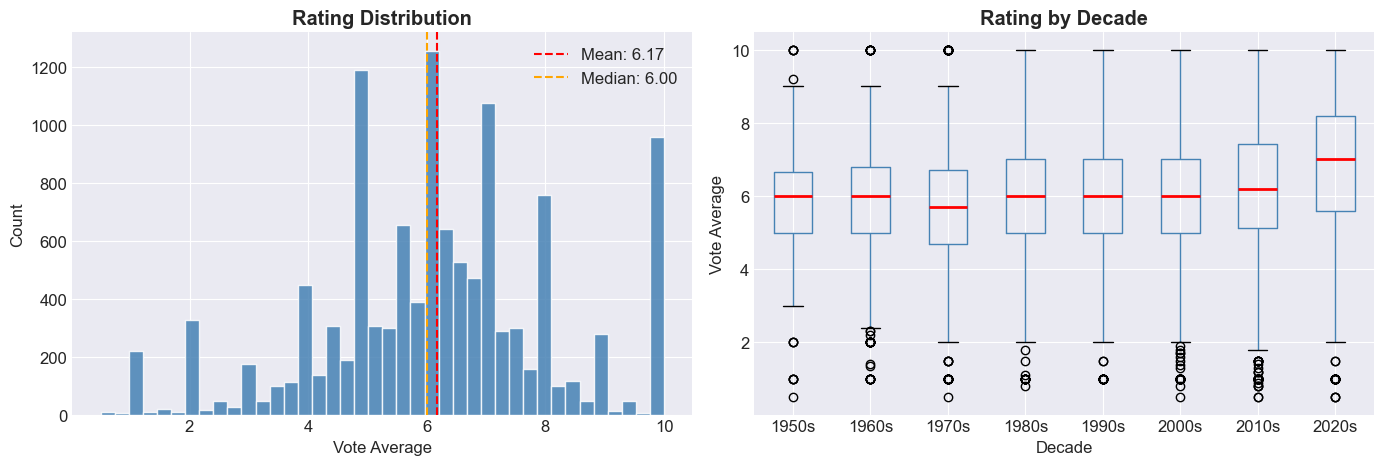

In [15]:
# ── 6.2 Rating Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
rated = movies[movies['vote_average'] > 0]['vote_average']
axes[0].hist(rated, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(rated.mean(), color='red', linestyle='--', label=f'Mean: {rated.mean():.2f}')
axes[0].axvline(rated.median(), color='orange', linestyle='--', label=f'Median: {rated.median():.2f}')
axes[0].set_xlabel('Vote Average')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].legend()

# Box plot by decade
movies_with_year = movies.dropna(subset=['year'])
movies_with_year = movies_with_year[
    (movies_with_year['year'] >= 1950) &
    (movies_with_year['year'] <= 2024) &
    (movies_with_year['vote_average'] > 0)
].copy()
movies_with_year['decade'] = (movies_with_year['year'] // 10 * 10).astype(int).astype(str) + 's'

decade_order = sorted(movies_with_year['decade'].unique())
movies_with_year.boxplot(column='vote_average', by='decade', ax=axes[1],
                         boxprops=dict(color='steelblue'),
                         whiskerprops=dict(color='steelblue'),
                         medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Rating by Decade', fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Vote Average')
plt.suptitle('')

plt.tight_layout()
plt.savefig('artifacts/eda_ratings.png', dpi=120, bbox_inches='tight')
plt.show()

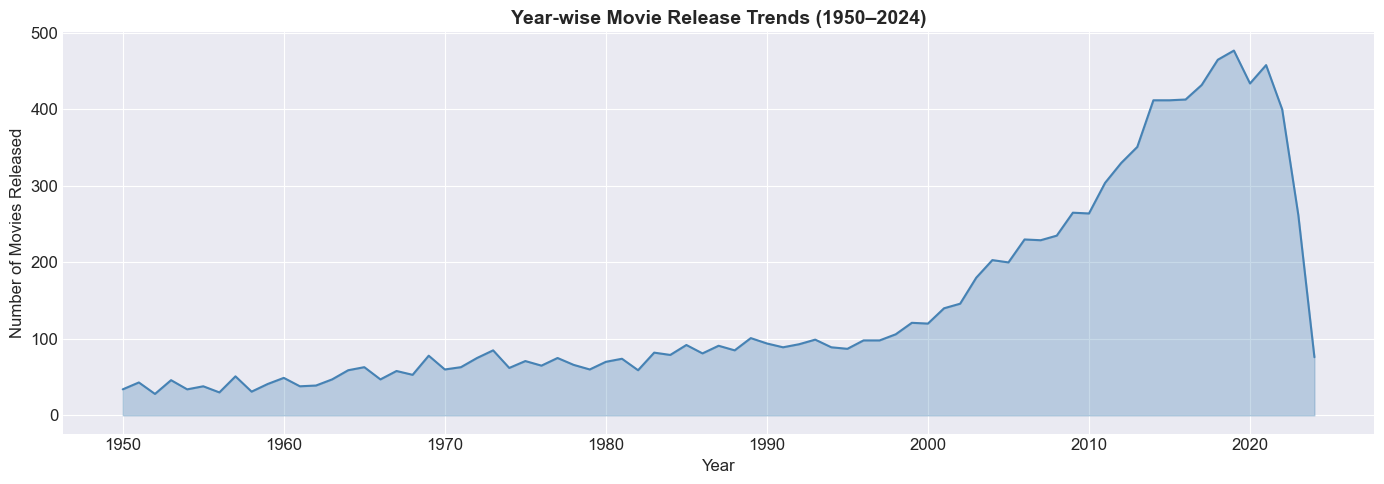

In [16]:
# ── 6.3 Year-wise Movie Release Trends ────────────────────
year_counts = (
    movies_with_year[movies_with_year['year'] >= 1950]
    .groupby('year').size()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='steelblue')
ax.plot(year_counts.index, year_counts.values, color='steelblue', linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies Released')
ax.set_title('Year-wise Movie Release Trends (1950–2024)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig('artifacts/eda_year_trends.png', dpi=120, bbox_inches='tight')
plt.show()

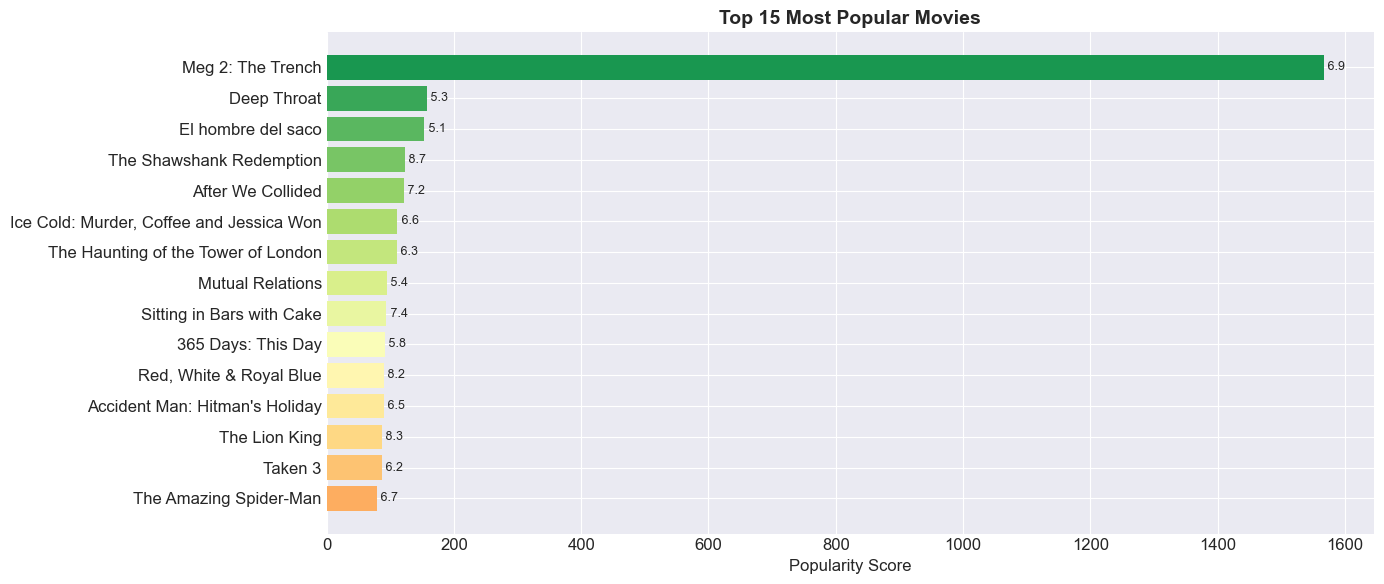

In [17]:
# ── 6.4 Most Popular Movies ───────────────────────────────
top_popular = movies.nlargest(15, 'popularity')[['title', 'popularity', 'vote_average']]

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_popular)))
bars = ax.barh(top_popular['title'].str[:40][::-1],
               top_popular['popularity'].values[::-1],
               color=colors)
ax.set_xlabel('Popularity Score')
ax.set_title('Top 15 Most Popular Movies', fontsize=14, fontweight='bold')
for bar, (_, row) in zip(bars, top_popular[::-1].iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f' {row["vote_average"]:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('artifacts/eda_popular.png', dpi=120, bbox_inches='tight')
plt.show()

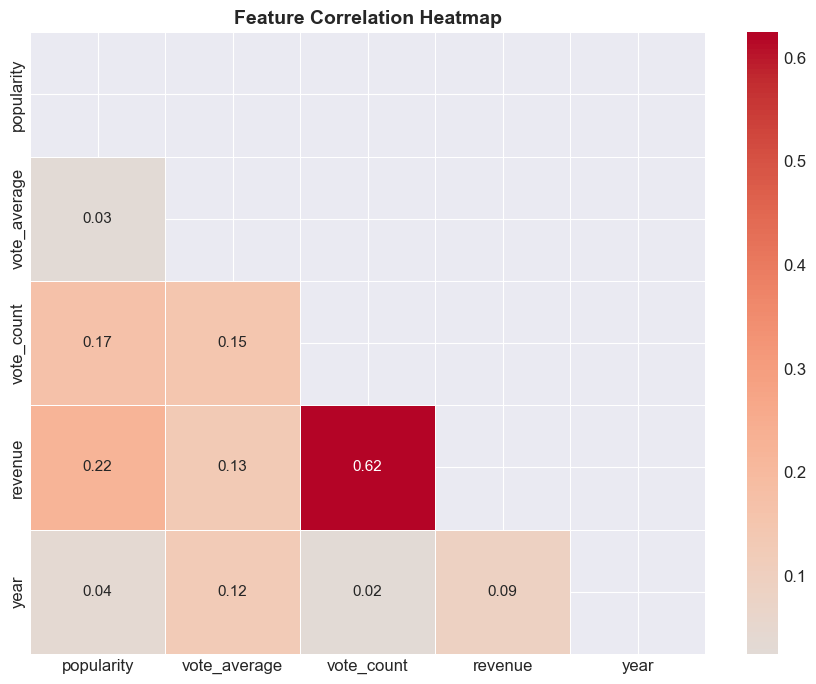

In [18]:
# ── 6.6 Correlation Heatmap ───────────────────────────────
num_cols = ['popularity', 'vote_average', 'vote_count']
if 'revenue' in movies.columns:
    num_cols.append('revenue')
if 'runtime' in movies.columns:
    num_cols.append('runtime')
if 'year' in movies.columns:
    num_cols.append('year')

corr_df = movies[num_cols].replace(0, np.nan).dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/eda_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

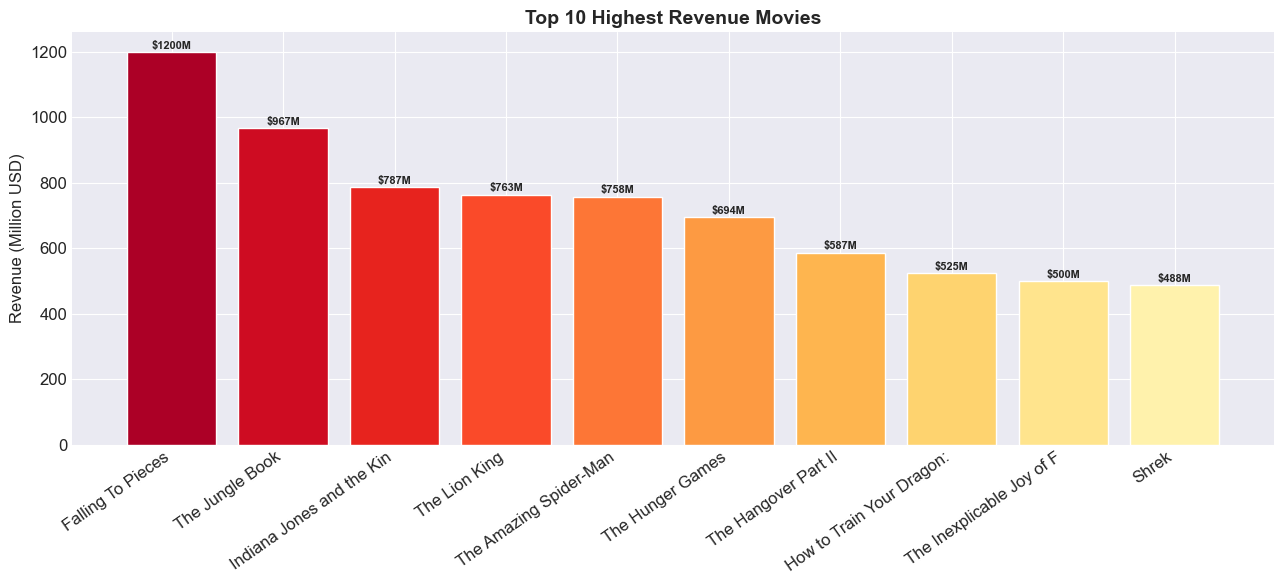

In [19]:
# ── 6.7 Top 10 Highest Revenue Movies ─────────────────────
if 'revenue' in movies.columns:
    top_revenue = movies[movies['revenue'] > 0].nlargest(10, 'revenue')[['title', 'revenue', 'vote_average']]
    top_revenue['revenue_M'] = top_revenue['revenue'] / 1_000_000

    fig, ax = plt.subplots(figsize=(13, 6))
    colors = sns.color_palette('YlOrRd', len(top_revenue))
    bars = ax.bar(top_revenue['title'].str[:25], top_revenue['revenue_M'],
                  color=colors[::-1], edgecolor='white')
    ax.set_ylabel('Revenue (Million USD)')
    ax.set_title('Top 10 Highest Revenue Movies', fontsize=14, fontweight='bold')
    plt.xticks(rotation=35, ha='right')
    for bar, val in zip(bars, top_revenue['revenue_M']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'${val:.0f}M', ha='center', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.savefig('artifacts/eda_revenue.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Revenue column not found in dataset.')

##  7. Machine Learning Model — Content-Based Recommender

**Approach:**
- Represent each movie as a TF-IDF / Count vector of its `tags`
- Compute pairwise cosine similarity
- For a query movie, return top-N most similar movies

**Optimization:**
- Use top 15,000 movies by vote_count (quality subset)
- max_features=5000 keeps vocabulary manageable
- Store only the movies list + vectorizer (not the full similarity matrix)


In [20]:
# ── Select subset for ML model ─────────────────────────────
# Use top 15K movies by vote_count for better recommendation quality
ML_SUBSET_SIZE = 15000

ml_movies = (
    movies[movies['tags'].str.strip() != '']
    .sort_values('vote_count', ascending=False)
    .head(ML_SUBSET_SIZE)
    .reset_index(drop=True)
)

print(f'ML subset shape: {ml_movies.shape}')
print(f'Sample titles: {list(ml_movies["title"].head(10))}')

ML subset shape: (15000, 15)
Sample titles: ['The Shawshank Redemption', 'The Hunger Games', 'The Lion King', 'The Truman Show', 'The Amazing Spider-Man', 'Hacksaw Ridge', 'Amélie', 'The Hangover Part II', 'Psycho', 'Bird Box']


In [21]:
# ── Vectorization: CountVectorizer ─────────────────────────
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(ml_movies['tags']).toarray()

print(f'Vector matrix shape: {vectors.shape}')
print(f'Vocabulary size: {len(cv.vocabulary_)}')

Vector matrix shape: (15000, 5000)
Vocabulary size: 5000


In [22]:
# ── Cosine Similarity ─────────────────────────────────────
# Compute on ML subset only
similarity = cosine_similarity(vectors)
print(f'Similarity matrix shape: {similarity.shape}')
print(f'Memory size: {similarity.nbytes / 1e6:.1f} MB')

Similarity matrix shape: (15000, 15000)
Memory size: 1800.0 MB


In [23]:
# ── Recommendation Function ───────────────────────────────
def recommend(movie_title, top_n=10):
    """
    Returns top_n most similar movies for a given title.
    
    Args:
        movie_title (str): Exact or partial movie title
        top_n (int): Number of recommendations to return
    
    Returns:
        pd.DataFrame: Recommended movies with metadata
    """
    # Fuzzy title matching (case-insensitive substring)
    mask = ml_movies['title'].str.lower().str.contains(
        movie_title.lower(), na=False, regex=False
    )
    matches = ml_movies[mask]

    if len(matches) == 0:
        print(f' Movie "{movie_title}" not found in dataset.')
        return pd.DataFrame()

    # Use first exact match if available, else first substring match
    exact = matches[matches['title'].str.lower() == movie_title.lower()]
    idx = exact.index[0] if len(exact) > 0 else matches.index[0]
    movie_name = ml_movies.loc[idx, 'title']
    print(f' Finding recommendations for: "{movie_name}"')

    # Get cosine similarity scores
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Skip the movie itself (index 0 after sort)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]

    rec_indices = [i[0] for i in sim_scores]
    rec_scores = [round(i[1], 4) for i in sim_scores]

    result = ml_movies.loc[rec_indices, ['title', 'genres', 'year', 'vote_average', 'popularity']].copy()
    result['similarity_score'] = rec_scores
    return result.reset_index(drop=True)


# ── Test the recommender ──────────────────────────────────
test_movie = ml_movies['title'].iloc[0]
print(f'Testing with: {test_movie}\n')
recs = recommend(test_movie, top_n=10)
recs

Testing with: The Shawshank Redemption

 Finding recommendations for: "The Shawshank Redemption"


,title,genres,year,vote_average,popularity,similarity_score
0,Att Stå Utanför Och Se In…,,2010.0,10.000,0.699,0.5522
1,The Year of the Tiger,Drama,2013.0,5.167,1.394,0.4693
2,King of Prison 2: The Prison War,"Action, Crime",2021.0,5.000,2.130,0.4485
3,Screwed,,2009.0,8.000,0.600,0.4198
4,Duffy of San Quentin,"Drama, Crime",1954.0,6.000,2.108,0.3369
5,Confessions of a Thug,"Drama, Music",2005.0,6.000,0.682,0.3294
6,True Story,"Crime, Drama, History",2015.0,6.265,9.607,0.3220
7,We'll Meet Again,"Drama, Thriller, Crime, Mystery",2002.0,4.700,4.097,0.3103
8,The Fence,"Thriller, Action, Crime",1994.0,10.000,0.823,0.3040
9,"The Farm: Angola, USA",Documentary,1998.0,7.100,0.805,0.3032


In [24]:
# ── Additional test ───────────────────────────────────────
# Try a well-known movie if present in dataset
for test in ['Inception', 'Avatar', 'The Dark Knight', ml_movies['title'].iloc[5]]:
    recs = recommend(test, top_n=5)
    if len(recs) > 0:
        print(f'\n Recommendations for "{test}":')
        print(recs[['title', 'year', 'vote_average', 'similarity_score']].to_string(index=False))
        break

 Movie "Inception" not found in dataset.
 Finding recommendations for: "Avatar"

 Recommendations for "Avatar":
             title   year  vote_average  similarity_score
           Lighter 1970.0           5.0            0.3086
         The Adult 2019.0           9.0            0.2817
        Otevři oči 1977.0          10.0            0.2572
   Good Intentions    NaN           0.0            0.2572
In Between Seasons 2018.0           6.8            0.2546


##  8. Save Artifacts for Streamlit App

In [25]:
os.makedirs('artifacts', exist_ok=True)

# Save movie dict (title, id, year, vote_average, genres, tags)
movie_dict_cols = ['title', 'genres', 'year', 'vote_average', 'popularity', 'tags']
if 'id' in ml_movies.columns:
    movie_dict_cols = ['id'] + movie_dict_cols
if 'overview' in ml_movies.columns:
    movie_dict_cols.append('overview')

movie_dict = ml_movies[[c for c in movie_dict_cols if c in ml_movies.columns]].to_dict()

with open('artifacts/movie_dict.pkl', 'wb') as f:
    pickle.dump(movie_dict, f)

with open('artifacts/similarity.pkl', 'wb') as f:
    pickle.dump(similarity, f)

print('Artifacts saved:')
print('   artifacts/movie_dict.pkl')
print('   artifacts/similarity.pkl')
print(f'   Movie count in artifact: {len(ml_movies)}')

Artifacts saved:
   artifacts/movie_dict.pkl
   artifacts/similarity.pkl
   Movie count in artifact: 15000


##  9. Model Evaluation — Sanity Checks

In [26]:
# Evaluate: genre overlap between input and recommendations
def genre_overlap_score(input_title, recommendations):
    """Compute average genre overlap as a proxy for recommendation quality."""
    input_row = ml_movies[ml_movies['title'].str.lower() == input_title.lower()]
    if len(input_row) == 0 or len(recommendations) == 0:
        return None
    input_genres = set(input_row.iloc[0]['genres_clean'].split()) if 'genres_clean' in ml_movies.columns else set()
    overlaps = []
    for _, row in recommendations.iterrows():
        rec_genres = set(row.get('genres', '').lower().replace(',', ' ').split())
        if len(input_genres | rec_genres) > 0:
            overlap = len(input_genres & rec_genres) / len(input_genres | rec_genres)
            overlaps.append(overlap)
    return round(np.mean(overlaps), 3) if overlaps else 0.0

# Run evaluation on 5 sample movies
eval_results = []
sample_titles = ml_movies['title'].sample(5, random_state=42).tolist()

for title in sample_titles:
    recs = recommend(title, top_n=10)
    avg_sim = recs['similarity_score'].mean() if len(recs) > 0 else 0
    avg_rating = recs['vote_average'].mean() if len(recs) > 0 else 0
    eval_results.append({
        'Movie': title,
        'Avg Similarity': round(avg_sim, 4),
        'Avg Rating of Recs': round(avg_rating, 2),
        'Num Recommendations': len(recs)
    })

eval_df = pd.DataFrame(eval_results)
print('\n Recommendation Quality Evaluation:')
eval_df

 Finding recommendations for: "Riding On A Horse And Squirting Out Of Control After Being Given Liquid By Her Boss Who She Hates Sex with You."
 Finding recommendations for: "Perfectly Natural 18"
 Finding recommendations for: "Alem-i Cin 5: Azap"
 Finding recommendations for: "Tanhaji: The Unsung Warrior"
 Finding recommendations for: "Deadly Mom Retreat"

 Recommendation Quality Evaluation:


,Movie,Avg Similarity,Avg Rating of Recs,Num Recommendations
0,Riding On A Horse And Squirting Out Of Control...,0.1846,3.99,10
1,Perfectly Natural 18,0.2295,7.49,10
2,Alem-i Cin 5: Azap,0.8944,7.19,10
3,Tanhaji: The Unsung Warrior,0.4107,4.51,10
4,Deadly Mom Retreat,0.4644,5.43,10


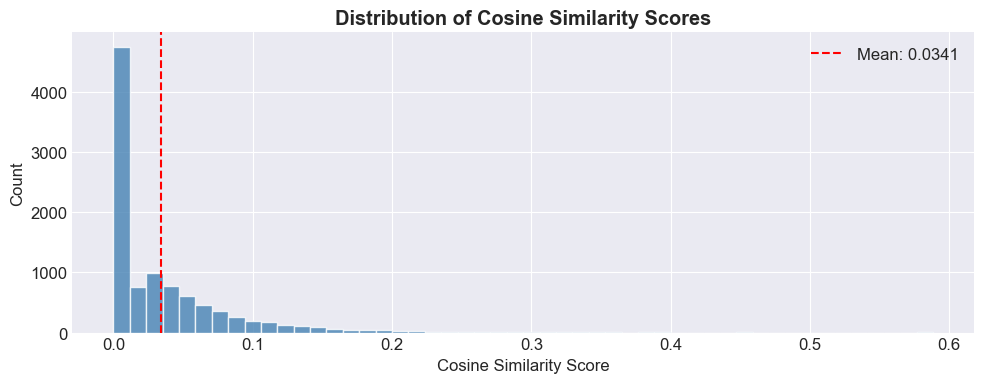

In [27]:
# Visualize similarity score distribution
fig, ax = plt.subplots(figsize=(10, 4))
# Flatten upper triangle of similarity matrix for distribution
sample_sim = similarity[np.random.choice(len(similarity), 100, replace=False)][:, :100].flatten()
sample_sim = sample_sim[sample_sim < 1.0]  # exclude self-similarity
ax.hist(sample_sim, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Cosine Similarity Scores', fontweight='bold')
ax.axvline(np.mean(sample_sim), color='red', linestyle='--',
           label=f'Mean: {np.mean(sample_sim):.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/eda_similarity_dist.png', dpi=120, bbox_inches='tight')
plt.show()